In [3]:
# import packages
import h5py # read h5

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from matplotlib import rc
from cycler import cycler

import numpy as np
import pandas as pd

from merge_h5_files import merge_preserve_time
import os
import glob
from tomlkit import date


# Figure format
rc = {'axes.facecolor':'white',
      'figure.figsize': (12, 6),
      'savefig.dpi': 600,
#       'axes.grid' : False,
      'axes.edgecolor' : '0.15',
      
      'font.family':'Times New Roman',
      'font.serif': ['Times New Roman', 'Times', 'STIXGeneral'],  # 备选
      # —— 数学字体（$...$ 内）——
      'mathtext.fontset': 'stix',     # 关键：让 μ、ε 等用 STIX（Times 风格）
      'axes.unicode_minus': False,    # 让负号显示为正常的连字符


      'axes.labelsize': 20,         # X、Y 轴标题字体
      'axes.labelweight': 'bold',   # X、Y 轴标题加粗
      'xtick.labelsize': 20,        # X轴刻度文字
      'ytick.labelsize': 20,        # Y轴刻度文字
      'legend.fontsize': 20,       # 图例字体

      # 线宽与颜色顺序
      'lines.linewidth': 2.25,      # 所有线条默认 2.25 pt
      'axes.prop_cycle': cycler('color', list(('k', 'r', 'b', 'g', 'm', 'c', 'y'))),

      # 刻度朝外 & 粗细
      'xtick.direction': 'out',
      'ytick.direction': 'out',
      'xtick.major.size': 6,
      'ytick.major.size': 6,
      'xtick.major.width': 2.0,
      'ytick.major.width': 2.0,

      # 坐标轴（内框）线宽
      'axes.linewidth': 2.0,
      } 
# lack of font size
plt.rcParams.update(rc)

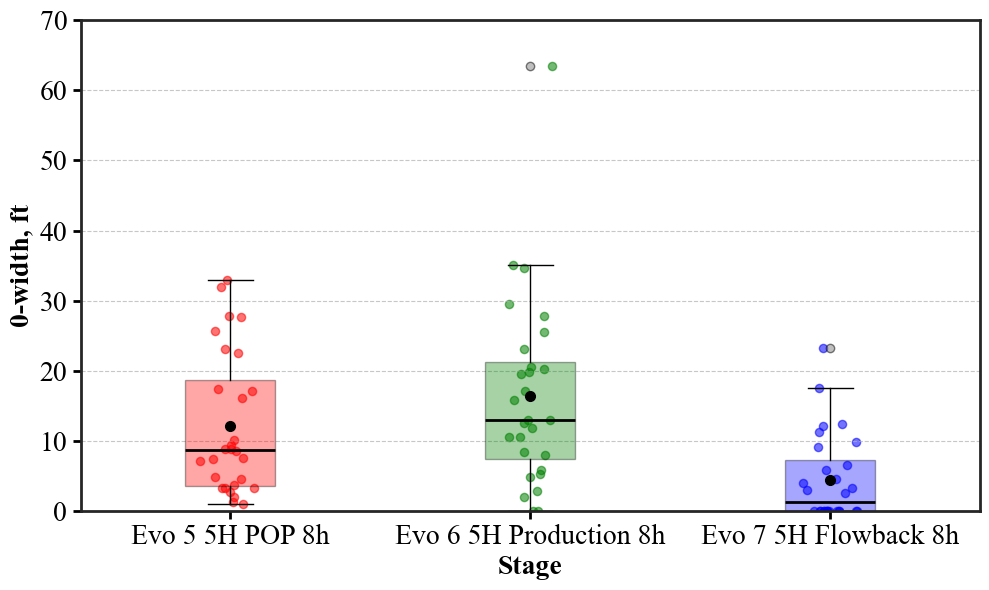

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 数据
# =========================
width_evo5 = [
    2.7 , 32, 27.7, 8.9, 23.1, 17.2, 16.1, 9.5, 7.5, 8.6,
    27.8, 4.9, 3.7, 7.2, 17.4, 2, 1.3, 25.7, 32.9, 8.9,
    4.6, 3.3, 3.3, 10.2, 1, 7.6, 3.3, 22.5
]

width_evo6 = [
    8.0, 20.2, 20.6, 0, 27.8,
    63.5, 17.2, 2.9, 8.5, 11.9,
    23.1, 5.3, 2.0, 5.9, 15.9,
    4.9, 0, 29.5, 35.1, 12.6,
    21.2/2, 21.2/2, 34.7, 26.1/2, 26.1/2,
    19.5, 19.8, 25.5
]

width_evo7 = [
    0, 23.2, 17.5, 0, 0, 12.2, 9.2, 0, 6.6, 2.6,
    11.3, 0, 0, 0, 12.5, 0, 0, 4.6, 9.9, 4,
    3.3, 3, 0, 5.9, 0, 0, 0, 0
]

# =========================
# 是否保留 0 值
# True  = 把 0 也算进去
# False = 去掉 0，只看有响应的 fracture width
# =========================
include_zero = True

data_raw = [np.array(width_evo5), np.array(width_evo6), np.array(width_evo7)]
labels = ['Evo 5 5H POP 8h', 'Evo 6 5H Production 8h', 'Evo 7 5H Flowback 8h']

if include_zero:
    data = data_raw
    title_suffix = '(including zeros)'
else:
    data = [d[d > 0] for d in data_raw]
    title_suffix = '(excluding zeros)'

# =========================
# 绘图
# =========================
fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    showmeans=True,
    meanline=False
)

# 给箱体上色
colors = ['red', 'green', 'blue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)

# 中位数、均值、离群点样式
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

for mean in bp['means']:
    mean.set_marker('o')
    mean.set_markerfacecolor('black')
    mean.set_markeredgecolor('black')
    mean.set_markersize(7)

for flier in bp['fliers']:
    flier.set(marker='o', markerfacecolor='gray', alpha=0.5, markersize=6)

# 可选：叠加散点，让每个数据点都能看见
for i, y in enumerate(data, start=1):
    x = np.random.normal(i, 0.04, size=len(y))  # 轻微抖动，避免重叠
    ax.scatter(x, y, alpha=0.55, s=35, color=colors[i-1])

ax.set_ylabel('0-width, ft')
ax.set_xlabel('Stage')

ax.set_ylim(0, 70)
ax.set_yticks(np.arange(0, 71, 10))
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

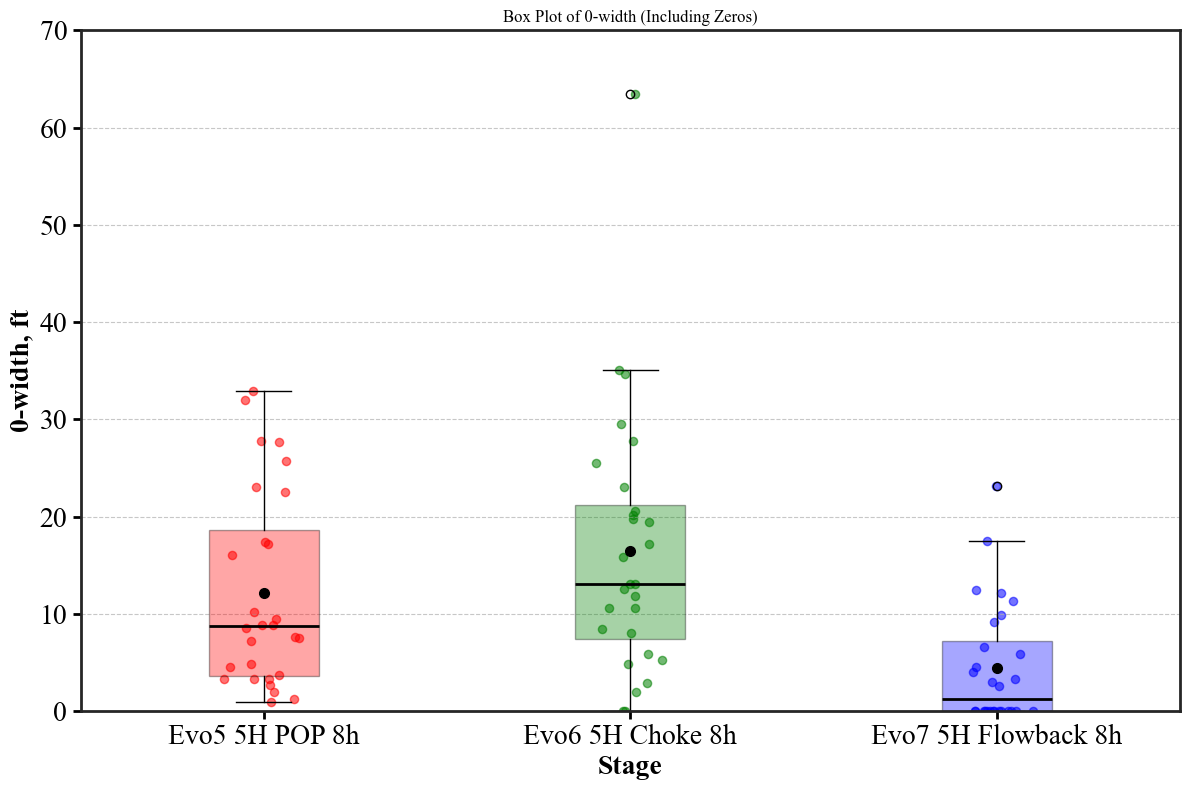

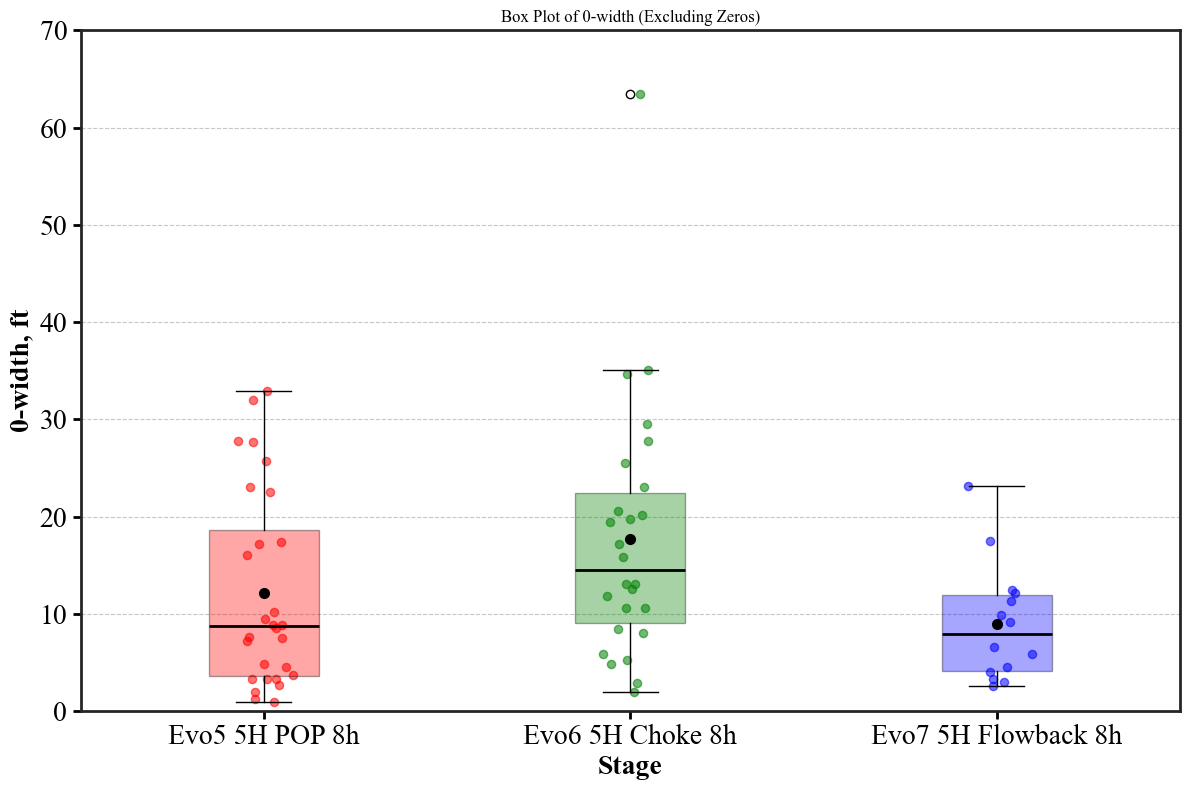

In [12]:
import matplotlib.pyplot as plt
import numpy as np

width_evo5 = [
    2.7 , 32, 27.7, 8.9, 23.1, 17.2, 16.1, 9.5, 7.5, 8.6,
    27.8, 4.9, 3.7, 7.2, 17.4, 2, 1.3, 25.7, 32.9, 8.9,
    4.6, 3.3, 3.3, 10.2, 1, 7.6, 3.3, 22.5
]

width_evo6 = [
    8.0, 20.2, 20.6, 0, 27.8,
    63.5, 17.2, 2.9, 8.5, 11.9,
    23.1, 5.3, 2.0, 5.9, 15.9,
    4.9, 0, 29.5, 35.1, 12.6,
    21.2/2, 21.2/2, 34.7, 26.1/2, 26.1/2,
    19.5, 19.8, 25.5
]

width_evo7 = [
    0, 23.2, 17.5, 0, 0, 12.2, 9.2, 0, 6.6, 2.6,
    11.3, 0, 0, 0, 12.5, 0, 0, 4.6, 9.9, 4,
    3.3, 3, 0, 5.9, 0, 0, 0, 0
]

data_raw = [np.array(width_evo5), np.array(width_evo6), np.array(width_evo7)]
labels = ['Evo5 5H POP 8h', 'Evo6 5H Choke 8h', 'Evo7 5H Flowback 8h']
colors = ['red', 'green', 'blue']

def draw_boxplot(data, title, savepath):
    fig, ax = plt.subplots(figsize=(12, 8))

    bp = ax.boxplot(
        data,
        labels=labels,
        patch_artist=True,
        showmeans=True
    )

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)

    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    for mean in bp['means']:
        mean.set_marker('o')
        mean.set_markerfacecolor('black')
        mean.set_markeredgecolor('black')
        mean.set_markersize(7)

    for i, y in enumerate(data, start=1):
        x = np.random.normal(i, 0.04, size=len(y))
        ax.scatter(x, y, alpha=0.55, s=35, color=colors[i-1])

    ax.set_ylabel('0-width, ft')
    ax.set_xlabel('Stage')
    ax.set_title(title)
    ax.set_ylim(0, 70)
    ax.set_yticks(np.arange(0, 71, 10))
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig(savepath, dpi=300)
    plt.show()

# 1) 保留 0 值
draw_boxplot(
    data_raw,
    'Box Plot of 0-width (Including Zeros)',
    'plot/0-width_boxplot_including_zeros.png'
)

# 2) 去掉 0 值
data_nonzero = [d[d > 0] for d in data_raw]
draw_boxplot(
    data_nonzero,
    'Box Plot of 0-width (Excluding Zeros)',
    'plot/0-width_boxplot_excluding_zeros.png'
)

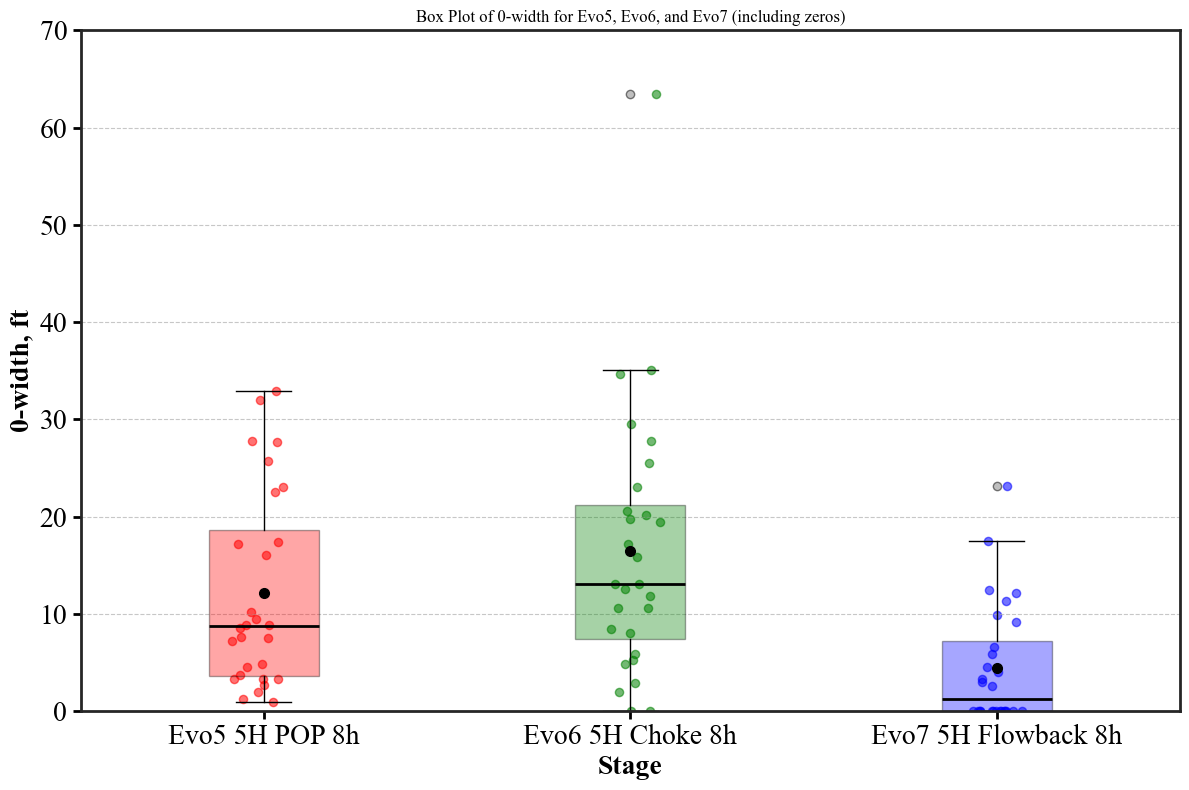

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 数据
# =========================
width_evo5 = [
    2.7 , 32, 27.7, 8.9, 23.1, 17.2, 16.1, 9.5, 7.5, 8.6,
    27.8, 4.9, 3.7, 7.2, 17.4, 2, 1.3, 25.7, 32.9, 8.9,
    4.6, 3.3, 3.3, 10.2, 1, 7.6, 3.3, 22.5
]

width_evo6 = [
    8.0, 20.2, 20.6, 0, 27.8,
    63.5, 17.2, 2.9, 8.5, 11.9,
    23.1, 5.3, 2.0, 5.9, 15.9,
    4.9, 0, 29.5, 35.1, 12.6,
    21.2/2, 21.2/2, 34.7, 26.1/2, 26.1/2,
    19.5, 19.8, 25.5
]

width_evo7 = [
    0, 23.2, 17.5, 0, 0, 12.2, 9.2, 0, 6.6, 2.6,
    11.3, 0, 0, 0, 12.5, 0, 0, 4.6, 9.9, 4,
    3.3, 3, 0, 5.9, 0, 0, 0, 0
]

# =========================
# 是否保留 0 值
# True  = 把 0 也算进去
# False = 去掉 0，只看有响应的 fracture width
# =========================
include_zero = True

data_raw = [np.array(width_evo5), np.array(width_evo6), np.array(width_evo7)]
labels = ['Evo5 5H POP 8h', 'Evo6 5H Choke 8h', 'Evo7 5H Flowback 8h']

if include_zero:
    data = data_raw
    title_suffix = '(including zeros)'
else:
    data = [d[d > 0] for d in data_raw]
    title_suffix = '(excluding zeros)'

# =========================
# 绘图
# =========================
fig, ax = plt.subplots(figsize=(12, 8))

bp = ax.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    showmeans=True,
    meanline=False
)

# 给箱体上色
colors = ['red', 'green', 'blue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)

# 中位数、均值、离群点样式
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

for mean in bp['means']:
    mean.set_marker('o')
    mean.set_markerfacecolor('black')
    mean.set_markeredgecolor('black')
    mean.set_markersize(7)

for flier in bp['fliers']:
    flier.set(marker='o', markerfacecolor='gray', alpha=0.5, markersize=6)

# 可选：叠加散点，让每个数据点都能看见
for i, y in enumerate(data, start=1):
    x = np.random.normal(i, 0.04, size=len(y))  # 轻微抖动，避免重叠
    ax.scatter(x, y, alpha=0.55, s=35, color=colors[i-1])

ax.set_ylabel('0-width, ft')
ax.set_xlabel('Stage')
ax.set_title(f'Box Plot of 0-width for Evo5, Evo6, and Evo7 {title_suffix}')

ax.set_ylim(0, 70)
ax.set_yticks(np.arange(0, 71, 10))
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('plot/0-width_boxplot_figure.png', dpi=300)
plt.show()

## 0-width

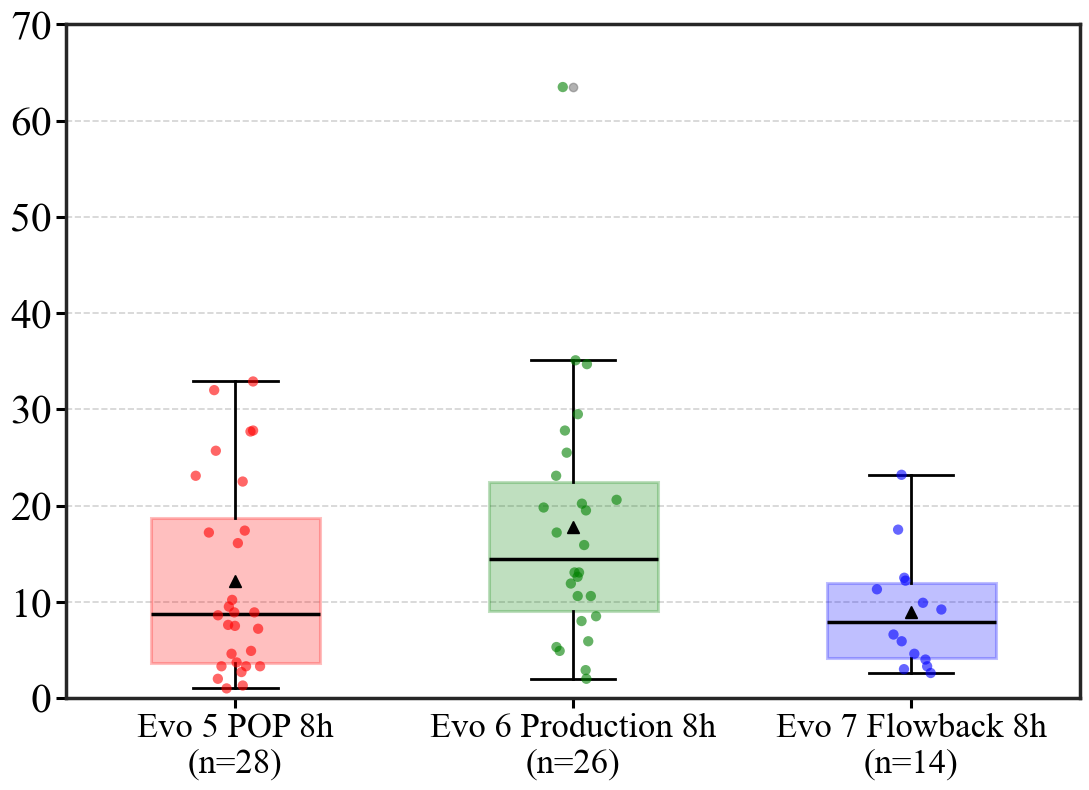

In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

# =========================================================
# 1. Data
# =========================================================
width_evo5 = np.array([
    2.7, 32, 27.7, 8.9, 23.1, 17.2, 16.1, 9.5, 7.5, 8.6,
    27.8, 4.9, 3.7, 7.2, 17.4, 2, 1.3, 25.7, 32.9, 8.9,
    4.6, 3.3, 3.3, 10.2, 1, 7.6, 3.3, 22.5
], dtype=float)

width_evo6 = np.array([
    8.0, 20.2, 20.6, 0, 27.8,
    63.5, 17.2, 2.9, 8.5, 11.9,
    23.1, 5.3, 2.0, 5.9, 15.9,
    4.9, 0, 29.5, 35.1, 12.6,
    21.2/2, 21.2/2, 34.7, 26.1/2, 26.1/2,
    19.5, 19.8, 25.5
], dtype=float)

width_evo7 = np.array([
    0, 23.2, 17.5, 0, 0, 12.2, 9.2, 0, 6.6, 2.6,
    11.3, 0, 0, 0, 12.5, 0, 0, 4.6, 9.9, 4,
    3.3, 3, 0, 5.9, 0, 0, 0, 0
], dtype=float)

# =========================================================
# 2. Keep only nonzero values
# =========================================================
data_nonzero = [
    width_evo5[width_evo5 > 0],
    width_evo6[width_evo6 > 0],
    width_evo7[width_evo7 > 0]
]

# labels
labels = [
    f'Evo 5 POP 8h\n(n={len(data_nonzero[0])})',
    f'Evo 6 Production 8h\n(n={len(data_nonzero[1])})',
    f'Evo 7 Flowback 8h\n(n={len(data_nonzero[2])})'
]

colors = ['red', 'green', 'blue']

# reproducible random jitter
rng = np.random.default_rng(42)

# =========================================================
# 3. Figure style (PPT / paper style)
# =========================================================
rc = {
    'axes.facecolor': 'white',
    'figure.figsize': (11, 8),
    'savefig.dpi': 600,
    'axes.edgecolor': '0.15',

    'font.family': 'Times New Roman',
    'font.serif': ['Times New Roman', 'Times', 'STIXGeneral'],
    'mathtext.fontset': 'stix',
    'axes.unicode_minus': False,

    'axes.labelsize': 24,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 25,
    'ytick.labelsize': 30,
    'legend.fontsize': 18,

    'axes.linewidth': 2.5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 7,
    'ytick.major.size': 7,
    'xtick.major.width': 2.2,
    'ytick.major.width': 2.2,
}
plt.rcParams.update(rc)

# =========================================================
# 4. Plot
# =========================================================
fig, ax = plt.subplots()

bp = ax.boxplot(
    data_nonzero,
    labels=labels,              # old-version compatible
    patch_artist=True,
    showmeans=True,
    widths=0.5,
    whis=1.5,
    boxprops=dict(linewidth=2.2),
    whiskerprops=dict(linewidth=2.0),
    capprops=dict(linewidth=2.0),
    medianprops=dict(color='black', linewidth=2.5),
    meanprops=dict(
        marker='^',
        markerfacecolor='black',
        markeredgecolor='black',
        markersize=8
    ),
    flierprops=dict(
        marker='o',
        markerfacecolor='gray',
        markeredgecolor='gray',
        markersize=6,
        alpha=0.6
    )
)

# color the box bodies
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.25)
    patch.set_edgecolor(c)

# overlay scatter points
for i, (y, c) in enumerate(zip(data_nonzero, colors), start=1):
    x = rng.normal(i, 0.06, size=len(y))
    ax.scatter(
        x, y,
        s=55,
        color=c,
        alpha=0.60,
        edgecolors='none',
        zorder=3
    )

# axis labels
# ax.set_xlabel('Stage')
# ax.set_ylabel('0-width, ft')

# no title
# ax.set_title(...)

# y-axis range and ticks
ax.set_ylim(0, 70)
ax.set_yticks(np.arange(0, 71, 10))

# grid
ax.grid(axis='y', linestyle='--', linewidth=1.2, alpha=0.55)

# thicker spines
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# tick style
ax.tick_params(axis='both', which='major', width=2.2, length=7)

# optional: remove top/right spines for cleaner publication style
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

plt.tight_layout()


plt.show()

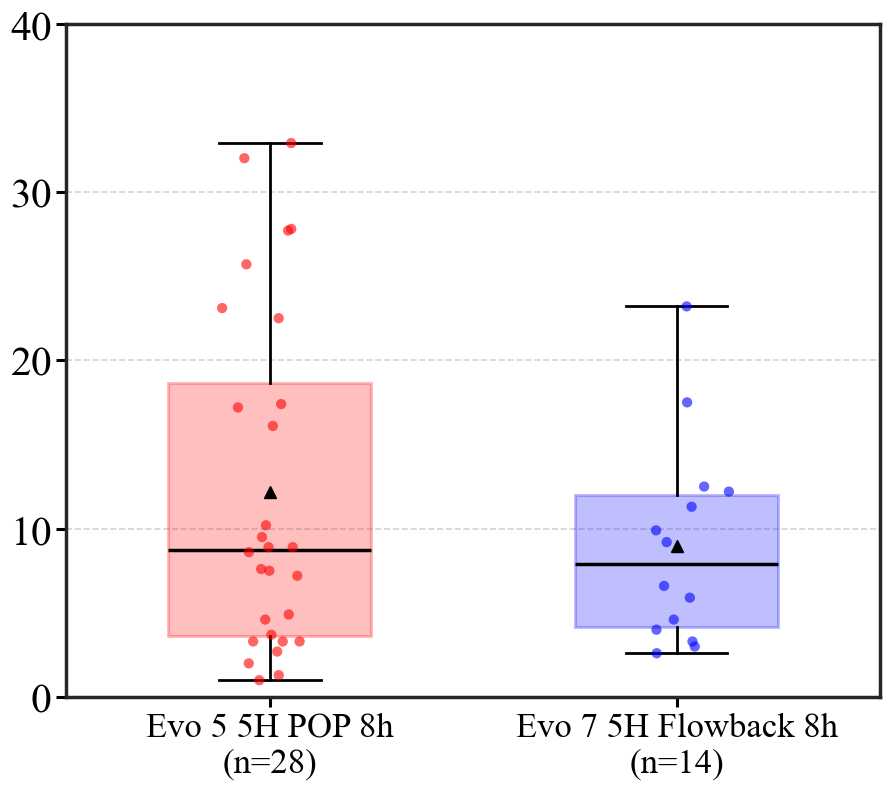

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

# =========================================================
# 1. Data
# =========================================================
width_evo5 = np.array([
    2.7, 32, 27.7, 8.9, 23.1, 17.2, 16.1, 9.5, 7.5, 8.6,
    27.8, 4.9, 3.7, 7.2, 17.4, 2, 1.3, 25.7, 32.9, 8.9,
    4.6, 3.3, 3.3, 10.2, 1, 7.6, 3.3, 22.5
], dtype=float)

width_evo7 = np.array([
    0, 23.2, 17.5, 0, 0, 12.2, 9.2, 0, 6.6, 2.6,
    11.3, 0, 0, 0, 12.5, 0, 0, 4.6, 9.9, 4,
    3.3, 3, 0, 5.9, 0, 0, 0, 0
], dtype=float)

# =========================================================
# 2. Keep only nonzero values
# =========================================================
data_nonzero = [
    width_evo5[width_evo5 > 0],
    width_evo7[width_evo7 > 0]
]

labels = [
    f'Evo 5 5H POP 8h\n(n={len(data_nonzero[0])})',
    f'Evo 7 5H Flowback 8h\n(n={len(data_nonzero[1])})'
]

colors = ['red', 'blue']

# reproducible random jitter
rng = np.random.default_rng(42)

# =========================================================
# 3. Figure style (PPT / paper style)
# =========================================================
rc = {
    'axes.facecolor': 'white',
    'figure.figsize': (9, 8),
    'savefig.dpi': 600,
    'axes.edgecolor': '0.15',

    'font.family': 'Times New Roman',
    'font.serif': ['Times New Roman', 'Times', 'STIXGeneral'],
    'mathtext.fontset': 'stix',
    'axes.unicode_minus': False,

    'axes.labelsize': 24,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 25,
    'ytick.labelsize': 30,
    'legend.fontsize': 18,

    'axes.linewidth': 2.5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 7,
    'ytick.major.size': 7,
    'xtick.major.width': 2.2,
    'ytick.major.width': 2.2,
}
plt.rcParams.update(rc)

# =========================================================
# 4. Plot
# =========================================================
fig, ax = plt.subplots()

bp = ax.boxplot(
    data_nonzero,
    labels=labels,
    patch_artist=True,
    showmeans=True,
    widths=0.5,
    whis=1.5,
    boxprops=dict(linewidth=2.2),
    whiskerprops=dict(linewidth=2.0),
    capprops=dict(linewidth=2.0),
    medianprops=dict(color='black', linewidth=2.5),
    meanprops=dict(
        marker='^',
        markerfacecolor='black',
        markeredgecolor='black',
        markersize=8
    ),
    flierprops=dict(
        marker='o',
        markerfacecolor='gray',
        markeredgecolor='gray',
        markersize=6,
        alpha=0.6
    )
)

# color the box bodies
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.25)
    patch.set_edgecolor(c)

# overlay scatter points
for i, (y, c) in enumerate(zip(data_nonzero, colors), start=1):
    x = rng.normal(i, 0.06, size=len(y))
    ax.scatter(
        x, y,
        s=55,
        color=c,
        alpha=0.60,
        edgecolors='none',
        zorder=3
    )

# y-axis range and ticks
ax.set_ylim(0, 40)
ax.set_yticks(np.arange(0, 41, 10))

# grid
ax.grid(axis='y', linestyle='--', linewidth=1.2, alpha=0.55)

# thicker spines
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# tick style
ax.tick_params(axis='both', which='major', width=2.2, length=7)

plt.tight_layout()
plt.show()

## peak magnitude

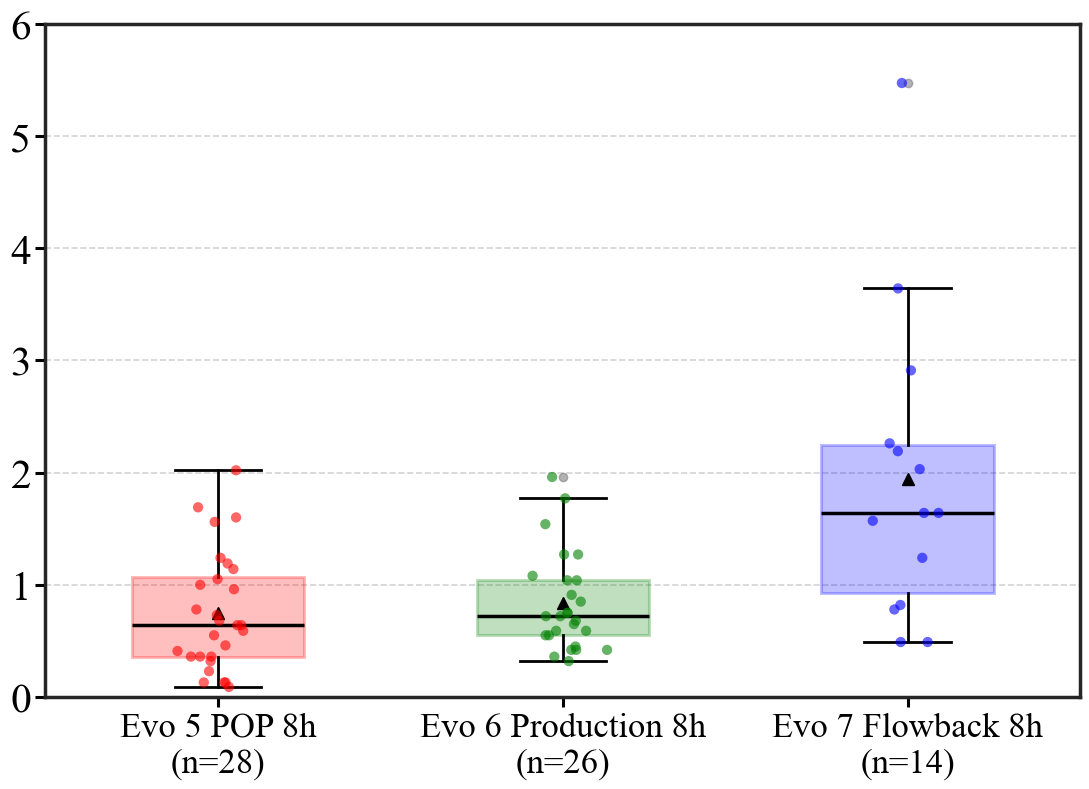

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

# =========================================================
# 1. Data
# =========================================================
top_evo5 = np.array([
    0.13, 0.78, 1.14, 0.64, 0.41, 0.36, 1.24, 0.36, 1.05, 1.00,
    2.02, 0.96, 0.68, 0.64, 1.19, 0.36, 0.13, 1.69, 1.60, 0.73,
    0.55, 0.13, 0.59, 1.56, 0.23, 0.32, 0.09, 0.46
], dtype=float)

top_evo6 = np.array([
    0.42, 0.91, 0.42, 0, 0.36, 1.96, 0.72, 0.45, 0.59, 0.72,
    1.54, 0.55, 0.42, 1.27, 0.65, 0.55, 0, 0.75, 1.77, 1.04,
    0.85, 0.75, 1.04, 1.27, 0.32, 0.68, 1.08, 0.59
], dtype=float)

top_evo7 = np.array([
    0.00, 2.19, 0.78, 0.00, 0.00, 5.47, 1.64, 0.00, 2.26, 0.49,
    1.57, 0.00, 0.00, 0.00, 0.49, 0.00, 0.00, 2.91, 2.03, 1.24,
    1.64, 0.82, 0.00, 3.64, 0.00, 0.00, 0.00, 0.00
], dtype=float)

# =========================================================
# 2. Keep only nonzero values
# =========================================================
data_nonzero = [
    top_evo5[top_evo5 > 0],
    top_evo6[top_evo6 > 0],
    top_evo7[top_evo7 > 0]
]

# labels
labels = [
    f'Evo 5 POP 8h\n(n={len(data_nonzero[0])})',
    f'Evo 6 Production 8h\n(n={len(data_nonzero[1])})',
    f'Evo 7 Flowback 8h\n(n={len(data_nonzero[2])})'
]

colors = ['red', 'green', 'blue']

# reproducible random jitter
rng = np.random.default_rng(42)

# =========================================================
# 3. Figure style (PPT / paper style)
# =========================================================
rc = {
    'axes.facecolor': 'white',
    'figure.figsize': (11, 8),
    'savefig.dpi': 600,
    'axes.edgecolor': '0.15',

    'font.family': 'Times New Roman',
    'font.serif': ['Times New Roman', 'Times', 'STIXGeneral'],
    'mathtext.fontset': 'stix',
    'axes.unicode_minus': False,

    'axes.labelsize': 24,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 25,
    'ytick.labelsize': 30,
    'legend.fontsize': 18,

    'axes.linewidth': 2.5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 7,
    'ytick.major.size': 7,
    'xtick.major.width': 2.2,
    'ytick.major.width': 2.2,
}
plt.rcParams.update(rc)

# =========================================================
# 4. Plot
# =========================================================
fig, ax = plt.subplots()

bp = ax.boxplot(
    data_nonzero,
    labels=labels,
    patch_artist=True,
    showmeans=True,
    widths=0.5,
    whis=1.5,
    boxprops=dict(linewidth=2.2),
    whiskerprops=dict(linewidth=2.0),
    capprops=dict(linewidth=2.0),
    medianprops=dict(color='black', linewidth=2.5),
    meanprops=dict(
        marker='^',
        markerfacecolor='black',
        markeredgecolor='black',
        markersize=8
    ),
    flierprops=dict(
        marker='o',
        markerfacecolor='gray',
        markeredgecolor='gray',
        markersize=6,
        alpha=0.6
    )
)

# color the box bodies
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.25)
    patch.set_edgecolor(c)

# overlay scatter points
for i, (y, c) in enumerate(zip(data_nonzero, colors), start=1):
    x = rng.normal(i, 0.06, size=len(y))
    ax.scatter(
        x, y,
        s=55,
        color=c,
        alpha=0.60,
        edgecolors='none',
        zorder=3
    )

# axis labels
# ax.set_xlabel('Stage')
# ax.set_ylabel(r'Strain Change Magnitude, $\mu\varepsilon$')

# no title

# y-axis range and ticks
ax.set_ylim(0, 6)
ax.set_yticks(np.arange(0, 6.1, 1))

# grid
ax.grid(axis='y', linestyle='--', linewidth=1.2, alpha=0.55)

# thicker spines
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# tick style
ax.tick_params(axis='both', which='major', width=2.2, length=7)

plt.tight_layout()
plt.show()

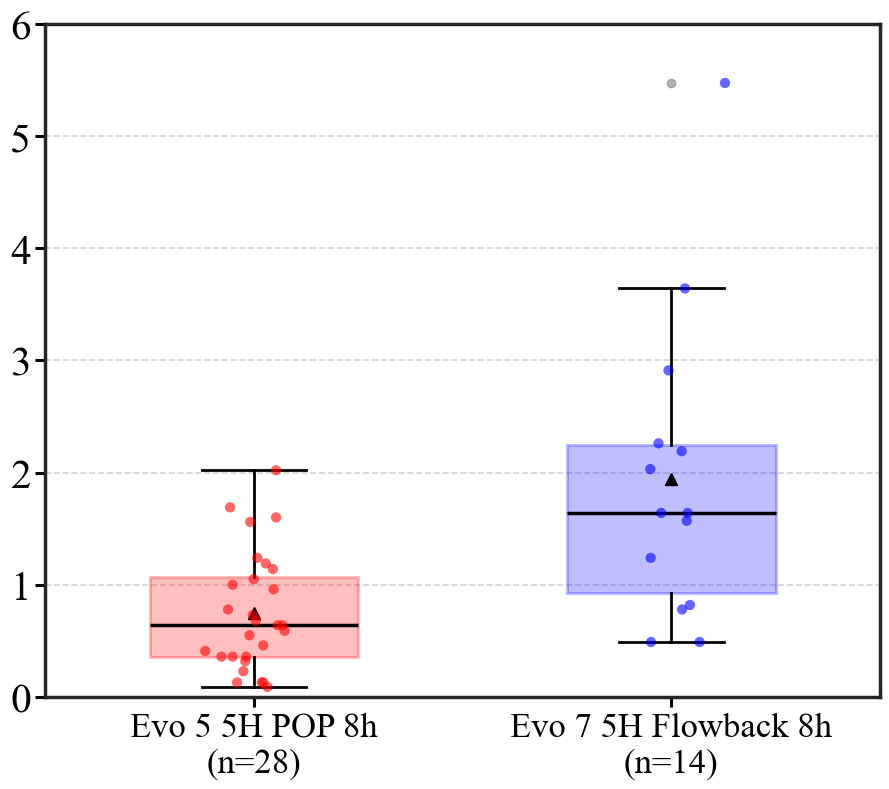

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

# =========================================================
# 1. Data
# =========================================================
top_evo5 = np.array([
    0.13, 0.78, 1.14, 0.64, 0.41, 0.36, 1.24, 0.36, 1.05, 1.00,
    2.02, 0.96, 0.68, 0.64, 1.19, 0.36, 0.13, 1.69, 1.60, 0.73,
    0.55, 0.13, 0.59, 1.56, 0.23, 0.32, 0.09, 0.46
], dtype=float)

top_evo7 = np.array([
    0.00, 2.19, 0.78, 0.00, 0.00, 5.47, 1.64, 0.00, 2.26, 0.49,
    1.57, 0.00, 0.00, 0.00, 0.49, 0.00, 0.00, 2.91, 2.03, 1.24,
    1.64, 0.82, 0.00, 3.64, 0.00, 0.00, 0.00, 0.00
], dtype=float)

# =========================================================
# 2. Keep only nonzero values
# =========================================================
data_nonzero = [
    top_evo5[top_evo5 > 0],
    top_evo7[top_evo7 > 0]
]

labels = [
    f'Evo 5 5H POP 8h\n(n={len(data_nonzero[0])})',
    f'Evo 7 5H Flowback 8h\n(n={len(data_nonzero[1])})'
]

colors = ['red', 'blue']

# reproducible random jitter
rng = np.random.default_rng(42)

# =========================================================
# 3. Figure style (PPT / paper style)
# =========================================================
rc = {
    'axes.facecolor': 'white',
    'figure.figsize': (9, 8),
    'savefig.dpi': 600,
    'axes.edgecolor': '0.15',

    'font.family': 'Times New Roman',
    'font.serif': ['Times New Roman', 'Times', 'STIXGeneral'],
    'mathtext.fontset': 'stix',
    'axes.unicode_minus': False,

    'axes.labelsize': 24,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 25,
    'ytick.labelsize': 30,
    'legend.fontsize': 18,

    'axes.linewidth': 2.5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 7,
    'ytick.major.size': 7,
    'xtick.major.width': 2.2,
    'ytick.major.width': 2.2,
}
plt.rcParams.update(rc)

# =========================================================
# 4. Plot
# =========================================================
fig, ax = plt.subplots()

bp = ax.boxplot(
    data_nonzero,
    labels=labels,
    patch_artist=True,
    showmeans=True,
    widths=0.5,
    whis=1.5,
    boxprops=dict(linewidth=2.2),
    whiskerprops=dict(linewidth=2.0),
    capprops=dict(linewidth=2.0),
    medianprops=dict(color='black', linewidth=2.5),
    meanprops=dict(
        marker='^',
        markerfacecolor='black',
        markeredgecolor='black',
        markersize=8
    ),
    flierprops=dict(
        marker='o',
        markerfacecolor='gray',
        markeredgecolor='gray',
        markersize=6,
        alpha=0.6
    )
)

# color the box bodies
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.25)
    patch.set_edgecolor(c)

# overlay scatter points
for i, (y, c) in enumerate(zip(data_nonzero, colors), start=1):
    x = rng.normal(i, 0.06, size=len(y))
    ax.scatter(
        x, y,
        s=55,
        color=c,
        alpha=0.60,
        edgecolors='none',
        zorder=3
    )

# axis labels
# ax.set_xlabel('Stage')
# ax.set_ylabel(r'Strain Change Magnitude, $\mu\varepsilon$')

# y-axis range and ticks
ax.set_ylim(0, 6)
ax.set_yticks(np.arange(0, 6.1, 1))

# grid
ax.grid(axis='y', linestyle='--', linewidth=1.2, alpha=0.55)

# thicker spines
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# tick style
ax.tick_params(axis='both', which='major', width=2.2, length=7)

plt.tight_layout()
plt.show()

## conductivity


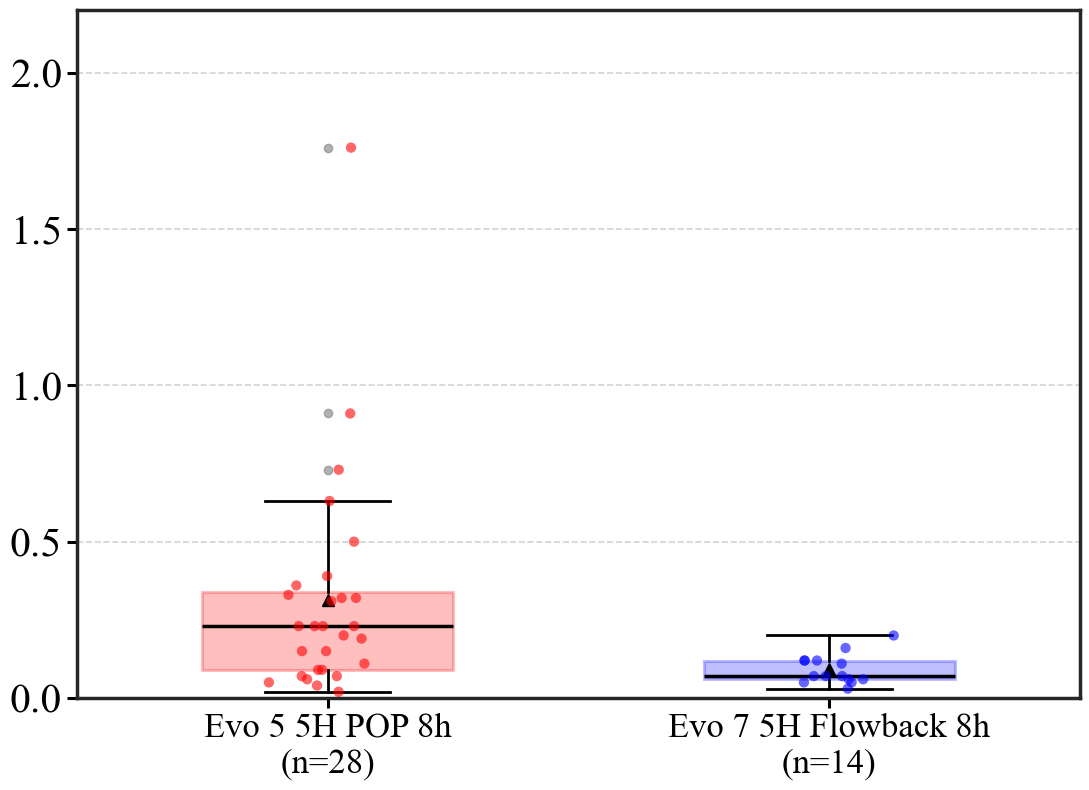

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

# =========================================================
# 1. Data
# =========================================================
cond_evo5 = np.array([
    0.07, 0.36, 0.91, 0.32, 0.05, 0.33, 0.31, 0.09, 0.39, 0.15,
    0.50, 1.76, 0.63, 0.19, 0.32, 0.07, 0.73, 0.23, 0.23, 0.15,
    0.09, 0.06, 0.11, 0.23, 0.23, 0.04, 0.20, 0.02
], dtype=float)

# cond_evo6 = np.array([
#     0.12, 0.32, 0.22, 0, 0.09, 0.13, 0.52, 0.11, 0.30, 0.80,
#     0.25, 0.06, 0.02, 0.21, 0.22, 0.09, 0, 0.32, 0.33, 0.24,
#     0.25, 0.33, 0.25, 0.26, 0.08, 0.50, 0.28, 0.23
# ], dtype=float)

cond_evo7 = np.array([
    0.00, 0.11, 0.07, 0.00, 0.00, 0.20, 0.12, 0.00, 0.07, 0.12,
    0.03, 0.00, 0.00, 0.00, 0.06, 0.00, 0.00, 0.07, 0.05, 0.12,
    0.06, 0.05, 0.00, 0.16, 0.00, 0.00, 0.00, 0.00
], dtype=float)

# =========================================================
# 2. Keep only nonzero values
# =========================================================
data_nonzero = [
    cond_evo5[cond_evo5 > 0],
    # cond_evo6[cond_evo6 > 0],
    cond_evo7[cond_evo7 > 0]
]
labels = [
    f'Evo 5 5H POP 8h\n(n={len(data_nonzero[0])})',
    # f'Evo 6 Production 8h\n(n={len(data_nonzero[1])})',
    f'Evo 7 5H Flowback 8h\n(n={len(data_nonzero[1])})'
]

colors = ['red',  'blue']

# reproducible random jitter
rng = np.random.default_rng(42)

# =========================================================
# 3. Figure style (PPT / paper style)
# =========================================================
rc = {
    'axes.facecolor': 'white',
    'figure.figsize': (11, 8),
    'savefig.dpi': 600,
    'axes.edgecolor': '0.15',

    'font.family': 'Times New Roman',
    'font.serif': ['Times New Roman', 'Times', 'STIXGeneral'],
    'mathtext.fontset': 'stix',
    'axes.unicode_minus': False,

    'axes.labelsize': 24,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 25,
    'ytick.labelsize': 30,
    'legend.fontsize': 18,

    'axes.linewidth': 2.5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 7,
    'ytick.major.size': 7,
    'xtick.major.width': 2.2,
    'ytick.major.width': 2.2,
}
plt.rcParams.update(rc)

# =========================================================
# 4. Plot
# =========================================================
fig, ax = plt.subplots()

bp = ax.boxplot(
    data_nonzero,
    labels=labels,
    patch_artist=True,
    showmeans=True,
    widths=0.5,
    whis=1.5,
    boxprops=dict(linewidth=2.2),
    whiskerprops=dict(linewidth=2.0),
    capprops=dict(linewidth=2.0),
    medianprops=dict(color='black', linewidth=2.5),
    meanprops=dict(
        marker='^',
        markerfacecolor='black',
        markeredgecolor='black',
        markersize=8
    ),
    flierprops=dict(
        marker='o',
        markerfacecolor='gray',
        markeredgecolor='gray',
        markersize=6,
        alpha=0.6
    )
)

# color the box bodies
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.25)
    patch.set_edgecolor(c)

# overlay scatter points
for i, (y, c) in enumerate(zip(data_nonzero, colors), start=1):
    x = rng.normal(i, 0.06, size=len(y))
    ax.scatter(
        x, y,
        s=55,
        color=c,
        alpha=0.60,
        edgecolors='none',
        zorder=3
    )

# axis labels
# ax.set_xlabel('Stage')
# ax.set_ylabel('Conductivity, mD·ft')

# no title

# y-axis range and ticks
ax.set_ylim(0, 2.2)
ax.set_yticks(np.arange(0, 2.21, 0.5))

# grid
ax.grid(axis='y', linestyle='--', linewidth=1.2, alpha=0.55)

# thicker spines
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# tick style
ax.tick_params(axis='both', which='major', width=2.2, length=7)

plt.tight_layout()
plt.show()